In [39]:
import pandas as pd
import numpy as np
import seaborn as sns

file_path = r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS602\Lab204\tips.csv"

df = pd.read_csv(file_path)


print("Shape (rows, columns):", df.shape)

print("\nHead:")
print(df.head())

print("\nDtypes:")
print(df.dtypes)

print("\nMissing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print(pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct.round(2)}))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumerical summary:")
print(df.describe())

cat_cols = df.select_dtypes(include=['category', 'object']).columns
print("\nCategorical columns overview:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

print("\nMin/Max sanity check:")
print(df[['total_bill', 'tip', 'size']].agg(['min', 'max']))

Shape (rows, columns): (244, 7)

Head:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Dtypes:
total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

Missing values:
            missing_count  missing_pct
total_bill              0          0.0
tip                     0          0.0
sex                     0          0.0
smoker                  0          0.0
day                     0          0.0
time                    0          0.0
size                    0          0.0

Duplicate rows: 1

Numerical summary:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    

In [40]:
dupe_mask = df.duplicated(keep=False)
print(df[dupe_mask])

df_clean = df.drop_duplicates(keep='first').reset_index(drop=True)
print(df_clean.shape)

impossible = df_clean[
    (df_clean['total_bill'] <= 0) |
    (df_clean['tip'] < 0) |
    (df_clean['size'] <= 0) |
    (df_clean['tip'] > df_clean['total_bill'])
]
print(len(impossible))
if len(impossible) > 0:
    print(impossible)

df_clean['tip_pct'] = df_clean['tip'] / df_clean['total_bill'] * 100

skew_kurt = pd.DataFrame({
    'skewness': df_clean[['total_bill', 'tip', 'tip_pct']].skew(),
    'kurtosis': df_clean[['total_bill', 'tip', 'tip_pct']].kurtosis()
})
print(skew_kurt.round(3))

def iqr_outlier_count(col):
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((df_clean[col] < lower) | (df_clean[col] > upper)).sum(), lower, upper

for col in ['total_bill', 'tip', 'tip_pct']:
    count, low, high = iqr_outlier_count(col)
    print(f"{col}: {count} outliers outside [{low:.2f}, {high:.2f}]")

for col in ['sex', 'smoker', 'day', 'time']:
    print(df_clean[col].value_counts())

     total_bill  tip     sex smoker   day   time  size
198        13.0  2.0  Female    Yes  Thur  Lunch     2
202        13.0  2.0  Female    Yes  Thur  Lunch     2
(243, 7)
0
            skewness  kurtosis
total_bill     1.127     1.206
tip            1.460     3.631
tip_pct        3.341    27.007
total_bill: 9 outliers outside [-2.81, 40.37]
tip: 8 outliers outside [-0.36, 5.94]
tip_pct: 4 outliers outside [3.45, 28.61]
sex
Male      157
Female     86
Name: count, dtype: int64
smoker
No     151
Yes     92
Name: count, dtype: int64
day
Sat     87
Sun     76
Thur    61
Fri     19
Name: count, dtype: int64
time
Dinner    176
Lunch      67
Name: count, dtype: int64


In [41]:
print(df_clean.sort_values('tip_pct', ascending=False).head(5))

     total_bill   tip     sex smoker  day    time  size    tip_pct
172        7.25  5.15    Male    Yes  Sun  Dinner     2  71.034483
178        9.60  4.00  Female    Yes  Sun  Dinner     2  41.666667
67         3.07  1.00  Female    Yes  Sat  Dinner     1  32.573290
231       11.61  3.39    Male     No  Sat  Dinner     2  29.198966
183       23.17  6.50    Male    Yes  Sun  Dinner     4  28.053517


In [42]:
df_clean['sex'] = df_clean['sex'].astype('category')
df_clean['smoker'] = df_clean['smoker'].astype('category')
df_clean['day'] = df_clean['day'].astype('category')
df_clean['time'] = df_clean['time'].astype('category')

df_clean['day'] = df_clean['day'].cat.set_categories(['Thur', 'Fri', 'Sat', 'Sun'], ordered=True)

print(df_clean.dtypes)
print(df_clean.shape)
print(df_clean.isnull().sum().sum())

df_clean.to_csv('tips_clean.csv', index=False)
print(df_clean.head())

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
tip_pct        float64
dtype: object
(243, 8)
0
   total_bill   tip     sex smoker  day    time  size    tip_pct
0       16.99  1.01  Female     No  Sun  Dinner     2   5.944673
1       10.34  1.66    Male     No  Sun  Dinner     3  16.054159
2       21.01  3.50    Male     No  Sun  Dinner     3  16.658734
3       23.68  3.31    Male     No  Sun  Dinner     2  13.978041
4       24.59  3.61  Female     No  Sun  Dinner     4  14.680765


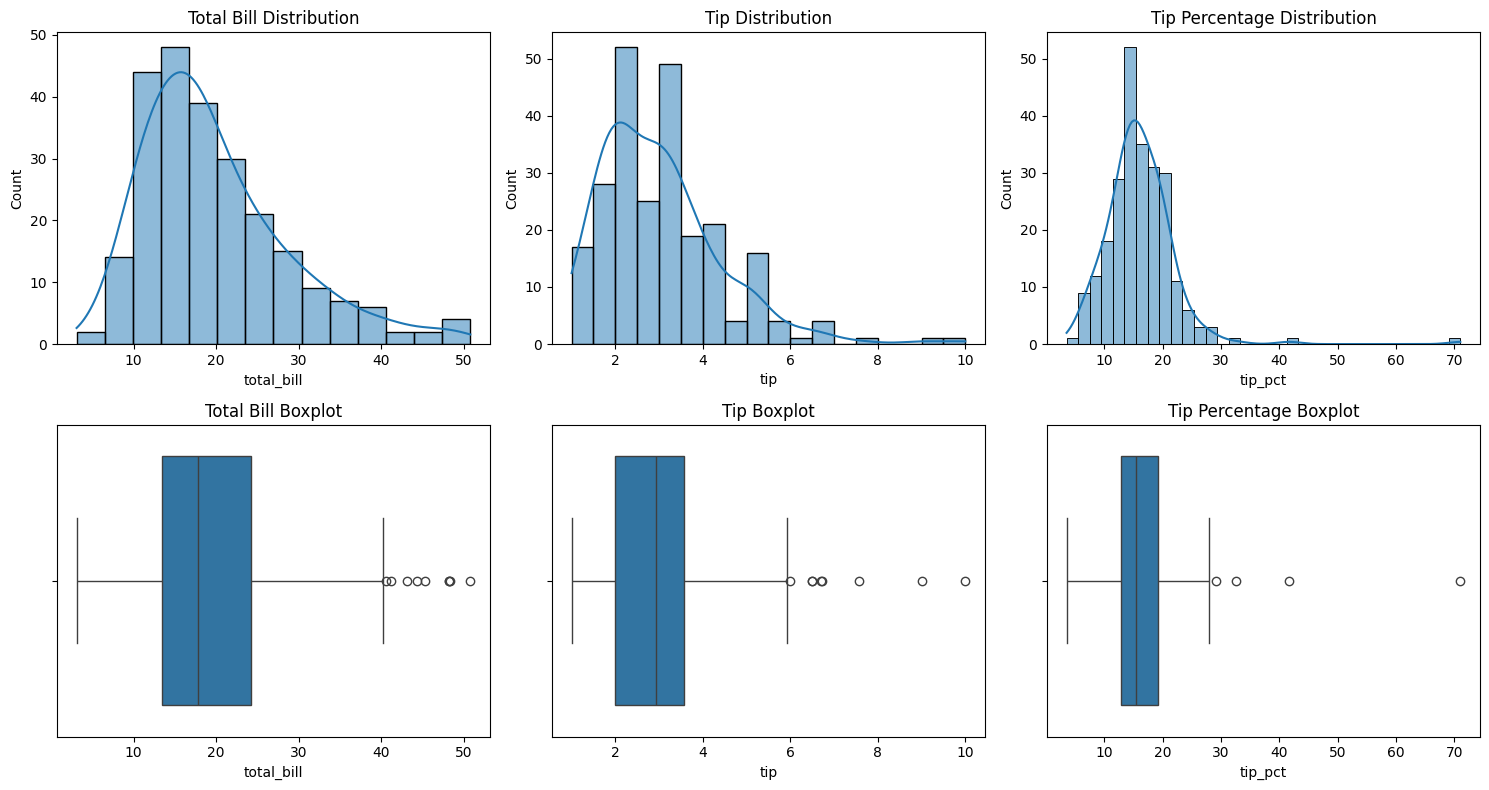

            total_bill    tip   size  tip_pct
total_bill       1.000  0.675  0.598   -0.339
tip              0.675  1.000  0.488    0.342
size             0.598  0.488  1.000   -0.143
tip_pct         -0.339  0.342 -0.143    1.000


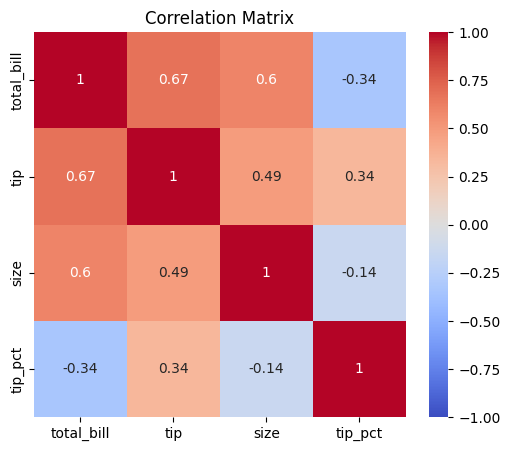

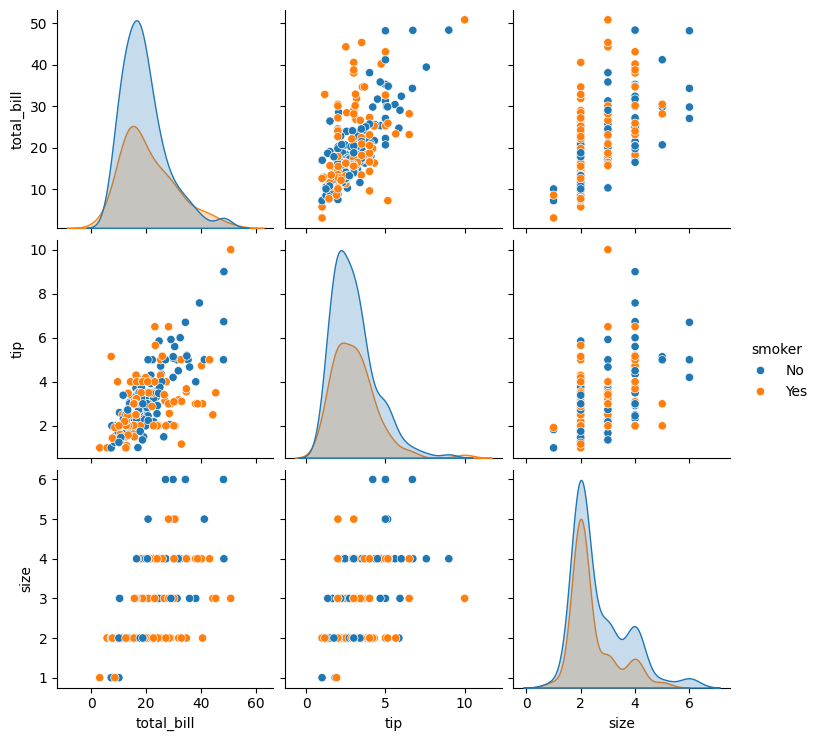

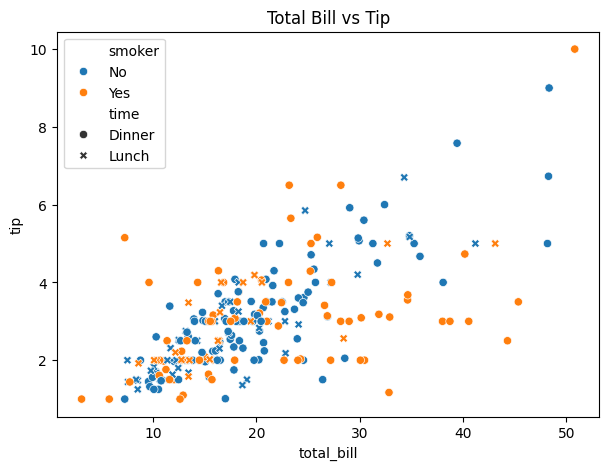

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df_clean['total_bill'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Total Bill Distribution')

sns.histplot(df_clean['tip'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Tip Distribution')

sns.histplot(df_clean['tip_pct'], kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Tip Percentage Distribution')

sns.boxplot(x=df_clean['total_bill'], ax=axes[1, 0])
axes[1, 0].set_title('Total Bill Boxplot')

sns.boxplot(x=df_clean['tip'], ax=axes[1, 1])
axes[1, 1].set_title('Tip Boxplot')

sns.boxplot(x=df_clean['tip_pct'], ax=axes[1, 2])
axes[1, 2].set_title('Tip Percentage Boxplot')

plt.tight_layout()
plt.show()

numeric_cols = ['total_bill', 'tip', 'size', 'tip_pct']
corr_matrix = df_clean[numeric_cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

sns.pairplot(df_clean, vars=['total_bill', 'tip', 'size'], hue='smoker')
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_clean, x='total_bill', y='tip', hue='smoker', style='time')
plt.title('Total Bill vs Tip')
plt.show()

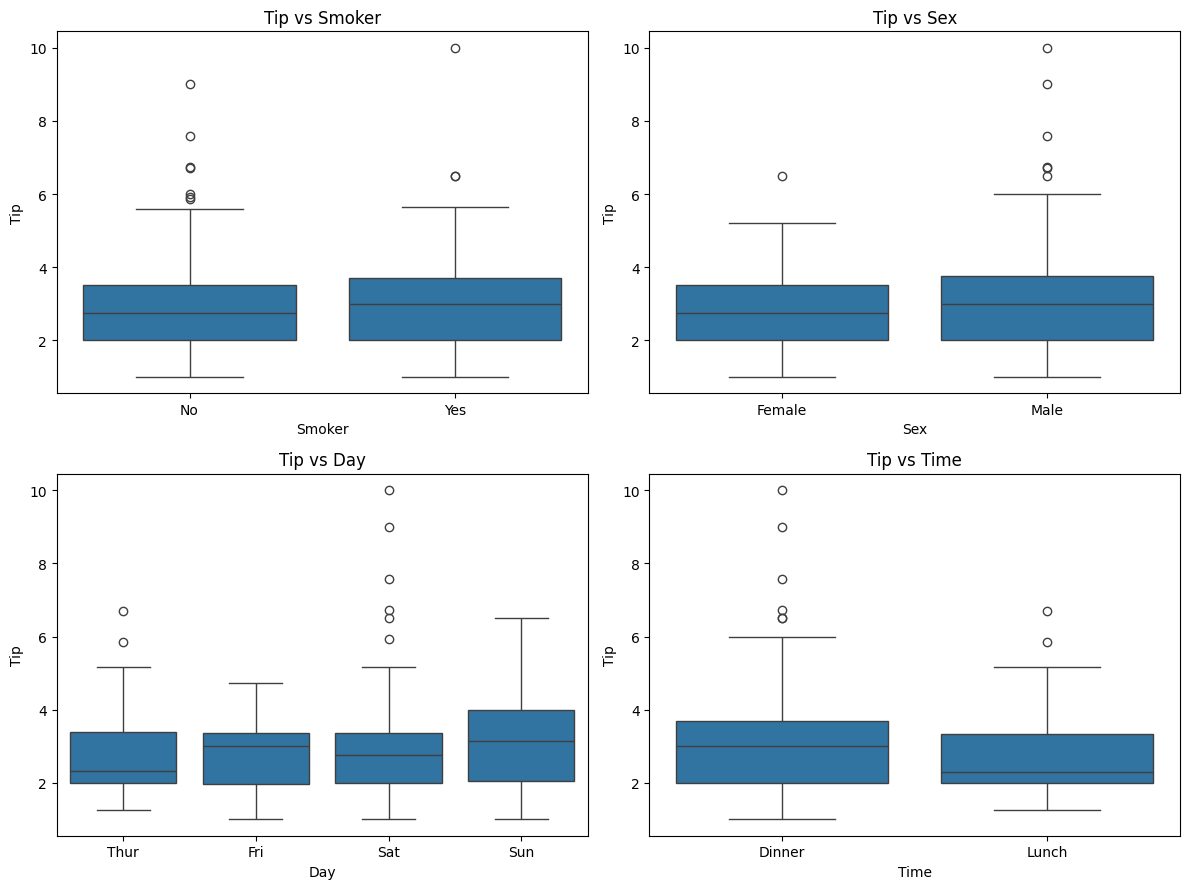

In [44]:
# Categorical comparisons: Tip vs Smoker, Sex, Day, and Time

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Tip vs Smoker
sns.boxplot(data=df_clean, x='smoker', y='tip', ax=axes[0, 0])
axes[0, 0].set_title('Tip vs Smoker')
axes[0, 0].set_xlabel('Smoker')
axes[0, 0].set_ylabel('Tip')

# Tip vs Sex
sns.boxplot(data=df_clean, x='sex', y='tip', ax=axes[0, 1])
axes[0, 1].set_title('Tip vs Sex')
axes[0, 1].set_xlabel('Sex')
axes[0, 1].set_ylabel('Tip')

# Tip vs Day
sns.boxplot(data=df_clean, x='day', y='tip', ax=axes[1, 0])
axes[1, 0].set_title('Tip vs Day')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Tip')

# Tip vs Time
sns.boxplot(data=df_clean, x='time', y='tip', ax=axes[1, 1])
axes[1, 1].set_title('Tip vs Time')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Tip')

plt.tight_layout()
plt.show()

## Hypothesis Testing

In [45]:
# Hypothesis Test 1: Tip vs Smoker

from scipy import stats

# Separate the two groups
smokers = df_clean[df_clean['smoker'] == 'Yes']['tip']
non_smokers = df_clean[df_clean['smoker'] == 'No']['tip']

alpha = 0.05

# Hypotheses
print("H0: The mean tip is the same for smokers and non-smokers.")
print("H1: The mean tip is different for smokers and non-smokers.")
print(f"Significance level (alpha): {alpha}")

# Group statistics
print("\nGroup Statistics:")
print(f"Smokers     - n = {len(smokers)}, mean = {smokers.mean():.3f}, std = {smokers.std():.3f}")
print(f"Non-smokers - n = {len(non_smokers)}, mean = {non_smokers.mean():.3f}, std = {non_smokers.std():.3f}")

# Shapiro-Wilk normality tests
shapiro_smokers = stats.shapiro(smokers)
shapiro_non_smokers = stats.shapiro(non_smokers)

print("\nShapiro-Wilk Normality Tests:")
print(f"Smokers     - statistic = {shapiro_smokers.statistic:.4f}, p-value = {shapiro_smokers.pvalue:.4f}")
print(f"Non-smokers - statistic = {shapiro_non_smokers.statistic:.4f}, p-value = {shapiro_non_smokers.pvalue:.4f}")

# Levene's test for equal variances
levene_test = stats.levene(smokers, non_smokers)

print("\nLevene's Test:")
print(f"Statistic = {levene_test.statistic:.4f}, p-value = {levene_test.pvalue:.4f}")

# Decide which test to use
normal_smokers = shapiro_smokers.pvalue > alpha
normal_non_smokers = shapiro_non_smokers.pvalue > alpha

if normal_smokers and normal_non_smokers:
    
    # If variances are equal, use standard t-test.
    # Otherwise, use Welch's t-test.
    equal_var = levene_test.pvalue > alpha
    
    test_stat, p_value = stats.ttest_ind(
        smokers,
        non_smokers,
        equal_var=equal_var
    )
    
    if equal_var:
        test_used = "Independent Two-Sample t-test"
    else:
        test_used = "Welch's t-test"

else:
    # If either group is not normally distributed
    test_stat, p_value = stats.mannwhitneyu(
        smokers,
        non_smokers,
        alternative='two-sided'
    )
    
    test_used = "Mann-Whitney U test"

# Final result
print("\nFinal Hypothesis Test:")
print(f"Test used: {test_used}")
print(f"Test statistic = {test_stat:.4f}")
print(f"p-value = {p_value:.4f}")

if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: There is a statistically significant difference in tip between smokers and non-smokers.")
else:
    print("\nDecision: Fail to reject H0")
    print("Conclusion: There is not enough statistical evidence to conclude that tip differs between smokers and non-smokers.")

H0: The mean tip is the same for smokers and non-smokers.
H1: The mean tip is different for smokers and non-smokers.
Significance level (alpha): 0.05

Group Statistics:
Smokers     - n = 92, mean = 3.020, std = 1.405
Non-smokers - n = 151, mean = 2.992, std = 1.377

Shapiro-Wilk Normality Tests:
Smokers     - statistic = 0.8809, p-value = 0.0000
Non-smokers - statistic = 0.9040, p-value = 0.0000

Levene's Test:
Statistic = 0.0199, p-value = 0.8879

Final Hypothesis Test:
Test used: Mann-Whitney U test
Test statistic = 7124.0000
p-value = 0.7380

Decision: Fail to reject H0
Conclusion: There is not enough statistical evidence to conclude that tip differs between smokers and non-smokers.


### Hypothesis Test 1: Tip vs Smoker — Conclusion

The Mann-Whitney U test was used because the Shapiro-Wilk normality tests indicated that the tip distributions for both smokers and non-smokers were not normally distributed (p < 0.05).

The test produced a U-statistic of 7124.0000 and a p-value of 0.7380. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis.

Therefore, there is insufficient statistical evidence to conclude that the distribution of tips differs significantly between smokers and non-smokers.

In [46]:
# Hypothesis Test 2: Tip vs Day
# One-Way ANOVA

from scipy import stats

alpha = 0.05

# Hypotheses
print("H0: The mean tip is the same across all four days.")
print("H1: At least one day's mean tip is different.")
print(f"Significance level (alpha): {alpha}")

# Separate tip values by day
thur = df_clean[df_clean['day'] == 'Thur']['tip']
fri = df_clean[df_clean['day'] == 'Fri']['tip']
sat = df_clean[df_clean['day'] == 'Sat']['tip']
sun = df_clean[df_clean['day'] == 'Sun']['tip']

# Group statistics
print("\nGroup Statistics:")
for day, group in [('Thur', thur), ('Fri', fri), ('Sat', sat), ('Sun', sun)]:
    print(f"{day}: n = {len(group)}, mean = {group.mean():.3f}, std = {group.std():.3f}")

# One-Way ANOVA
anova_stat, p_value = stats.f_oneway(thur, fri, sat, sun)

print("\nOne-Way ANOVA:")
print(f"F-statistic = {anova_stat:.4f}")
print(f"p-value = {p_value:.4f}")

# Decision
if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: There is a statistically significant difference in mean tip across the four days.")
else:
    print("\nDecision: Fail to reject H0")
    print("Conclusion: There is not enough statistical evidence to conclude that mean tip differs across the four days.")

H0: The mean tip is the same across all four days.
H1: At least one day's mean tip is different.
Significance level (alpha): 0.05

Group Statistics:
Thur: n = 61, mean = 2.784, std = 1.246
Fri: n = 19, mean = 2.735, std = 1.020
Sat: n = 87, mean = 2.993, std = 1.631
Sun: n = 76, mean = 3.255, std = 1.235

One-Way ANOVA:
F-statistic = 1.5983
p-value = 0.1904

Decision: Fail to reject H0
Conclusion: There is not enough statistical evidence to conclude that mean tip differs across the four days.


### Hypothesis Test 2: Tip vs Day — Conclusion

A One-Way ANOVA was performed to determine whether the mean tip differs across Thursday, Friday, Saturday, and Sunday.

The test produced an F-statistic of 1.5983 and a p-value of 0.1904. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis.

Therefore, there is insufficient statistical evidence to conclude that the mean tip differs significantly across the four days of the week.

In [47]:
# Descriptive Statistics for Numerical Features

numeric_cols = ['total_bill', 'tip', 'size', 'tip_pct']

descriptive_stats = pd.DataFrame({
    'Mean': df_clean[numeric_cols].mean(),
    'Median': df_clean[numeric_cols].median(),
    'Std Dev': df_clean[numeric_cols].std(),
    'IQR': df_clean[numeric_cols].quantile(0.75) - df_clean[numeric_cols].quantile(0.25),
    'Skewness': df_clean[numeric_cols].skew(),
    'Kurtosis': df_clean[numeric_cols].kurtosis()
})

print("Descriptive Statistics:")
display(descriptive_stats.round(3))

Descriptive Statistics:


,Mean,Median,Std Dev,IQR,Skewness,Kurtosis
total_bill,19.814,17.810,8.910,10.795,1.127,1.206
tip,3.002,2.920,1.385,1.575,1.460,3.631
size,2.572,2.000,0.952,1.000,1.442,1.712
tip_pct,16.083,15.522,6.120,6.291,3.341,27.007


Statistical Modeling & Diagnostics

In [48]:
# Train-Test Split

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_clean,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (194, 8)
Testing set shape: (49, 8)


In [49]:
# Define Target Variable (Y) and Predictor Variables (X)

target = 'tip'

predictors = [
    'total_bill',
    'size',
    'sex',
    'smoker',
    'day',
    'time'
]

X_train_raw = train_df[predictors]
y_train = train_df[target]

print("Target variable (Y):", target)
print("\nPredictor variables (X):")
print(predictors)

print("\nX_train shape:", X_train_raw.shape)
print("y_train shape:", y_train.shape)

print("\nFirst 5 rows of X_train:")
display(X_train_raw.head())

print("\nFirst 5 values of y_train:")
display(y_train.head())

Target variable (Y): tip

Predictor variables (X):
['total_bill', 'size', 'sex', 'smoker', 'day', 'time']

X_train shape: (194, 6)
y_train shape: (194,)

First 5 rows of X_train:


,total_bill,size,sex,smoker,day,time
115,17.31,2,Female,No,Sun,Dinner
207,24.27,2,Male,Yes,Sat,Dinner
158,13.39,2,Female,No,Sun,Dinner
132,11.17,2,Female,No,Thur,Lunch
84,15.98,2,Male,No,Thur,Lunch



First 5 values of y_train:


115    3.50
207    2.03
158    2.61
132    1.50
84     2.03
Name: tip, dtype: float64

With drop_first=True, the reference categories are Female, No, Thur, and Dinner, so a value of 1 indicates the alternative category and 0 indicates the reference category.




In [50]:
# Encode Categorical Predictors for OLS

X_train = pd.get_dummies(
    X_train_raw,
    columns=['sex', 'smoker', 'day', 'time'],
    drop_first=True,
    dtype=float
)

print("Encoded X_train shape:", X_train.shape)

print("\nEncoded predictor columns:")
print(X_train.columns.tolist())

print("\nFirst 5 rows of encoded X_train:")
display(X_train.head())

Encoded X_train shape: (194, 8)

Encoded predictor columns:
['total_bill', 'size', 'sex_Male', 'smoker_Yes', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Lunch']

First 5 rows of encoded X_train:


,total_bill,size,sex_Male,smoker_Yes,day_Fri,day_Sat,day_Sun,time_Lunch
115,17.31,2,0.0,0.0,0.0,0.0,1.0,0.0
207,24.27,2,1.0,1.0,0.0,1.0,0.0,0.0
158,13.39,2,0.0,0.0,0.0,0.0,1.0,0.0
132,11.17,2,0.0,0.0,0.0,0.0,0.0,1.0
84,15.98,2,1.0,0.0,0.0,0.0,0.0,1.0


In [51]:
# Add Intercept to the Predictor Matrix

import statsmodels.api as sm

X_train = sm.add_constant(X_train)

print("X_train shape after adding intercept:", X_train.shape)

print("\nDesign matrix columns:")
print(X_train.columns.tolist())

print("\nFirst 5 rows of the final design matrix:")
display(X_train.head())

X_train shape after adding intercept: (194, 9)

Design matrix columns:
['const', 'total_bill', 'size', 'sex_Male', 'smoker_Yes', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Lunch']

First 5 rows of the final design matrix:


,const,total_bill,size,sex_Male,smoker_Yes,day_Fri,day_Sat,day_Sun,time_Lunch
115,1.0,17.31,2,0.0,0.0,0.0,0.0,1.0,0.0
207,1.0,24.27,2,1.0,1.0,0.0,1.0,0.0,0.0
158,1.0,13.39,2,0.0,0.0,0.0,0.0,1.0,0.0
132,1.0,11.17,2,0.0,0.0,0.0,0.0,0.0,1.0
84,1.0,15.98,2,1.0,0.0,0.0,0.0,0.0,1.0


### Multiple Linear Regression — OLS Model

A multiple linear regression model was fitted using `statsmodels` OLS, with `tip` as the dependent variable and the selected numerical and categorical predictors as independent variables.
The model summary provides coefficient estimates, p-values, confidence intervals, R², and adjusted R².

In [52]:
# ============================================================
# Multiple Linear Regression using Statsmodels OLS
# ============================================================

# Fit the OLS model
model = sm.OLS(y_train, X_train).fit()

# Display the complete regression summary
print("Multiple Linear Regression — OLS Results")
print("=" * 60)
print(model.summary())

Multiple Linear Regression — OLS Results
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     18.56
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           2.76e-20
Time:                        23:24:59   Log-Likelihood:                -273.62
No. Observations:                 194   AIC:                             565.2
Df Residuals:                     185   BIC:                             594.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

### Regression Coefficient Interpretation

The fitted OLS model explains 44.5% of the variation in tip, with an adjusted R² of 42.1%.
At the 5% significance level, `total_bill` and `size` are statistically significant predictors of `tip`, while the remaining predictors are not individually significant.

In [53]:
# ============================================================
# Regression Coefficients and Model Statistics
# ============================================================

# Create a clean coefficient table
coef_table = pd.DataFrame({
    'Coefficient': model.params,
    'Std Error': model.bse,
    't-statistic': model.tvalues,
    'p-value': model.pvalues,
    'CI Lower (95%)': model.conf_int()[0],
    'CI Upper (95%)': model.conf_int()[1]
})

print("Regression Coefficient Table")
print("=" * 80)
display(coef_table.round(4))

# Overall model statistics
print("\nOverall Model Statistics")
print("=" * 50)
print(f"R-squared:           {model.rsquared:.4f}")
print(f"Adjusted R-squared:  {model.rsquared_adj:.4f}")
print(f"F-statistic:         {model.fvalue:.4f}")
print(f"F-test p-value:      {model.f_pvalue:.4e}")
print(f"Observations:        {int(model.nobs)}")

# Identify statistically significant predictors
significant = model.pvalues[model.pvalues < 0.05].index.tolist()
significant = [x for x in significant if x != 'const']

print("\nStatistically significant predictors (alpha = 0.05):")
print(significant)

Regression Coefficient Table


,Coefficient,Std Error,t-statistic,p-value,CI Lower (95%),CI Upper (95%)
const,0.6023,0.5197,1.1590,0.2480,-0.4230,1.6275
total_bill,0.0855,0.0110,7.7819,0.0000,0.0638,0.1072
size,0.2110,0.1016,2.0774,0.0391,0.0106,0.4114
sex_Male,0.0182,0.1551,0.1171,0.9069,-0.2879,0.3242
smoker_Yes,-0.0521,0.1603,-0.3252,0.7454,-0.3684,0.2641
day_Fri,0.0498,0.3953,0.1261,0.8998,-0.7301,0.8298
day_Sat,0.1531,0.4855,0.3154,0.7528,-0.8048,1.1110
day_Sun,0.2176,0.4861,0.4477,0.6549,-0.7413,1.1765
time_Lunch,0.1947,0.4542,0.4286,0.6687,-0.7015,1.0908



Overall Model Statistics
R-squared:           0.4452
Adjusted R-squared:  0.4213
F-statistic:         18.5598
F-test p-value:      2.7601e-20
Observations:        194

Statistically significant predictors (alpha = 0.05):
['total_bill', 'size']


In [54]:
# ============================================================
# Coefficient Interpretation
# ============================================================

print("Coefficient Interpretation")
print("=" * 80)

print(f"Intercept: {model.params['const']:.4f}")
print("The intercept represents the predicted tip for the reference categories")
print("(Female, Non-smoker, Thursday, Dinner) when numerical predictors are zero.")

print(f"\nTotal Bill: {model.params['total_bill']:.4f}")
print(
    f"For every 1-unit increase in total bill, the predicted tip increases "
    f"by approximately {model.params['total_bill']:.4f} units, "
    f"holding all other predictors constant."
)

print(f"\nSize: {model.params['size']:.4f}")
print(
    f"For each additional person in the party, the predicted tip increases "
    f"by approximately {model.params['size']:.4f} units, "
    f"holding all other predictors constant."
)

print(f"\nMale vs Female: {model.params['sex_Male']:.4f}")
print(
    "Male customers are predicted to give approximately "
    f"{model.params['sex_Male']:.4f} more in tip than female customers, "
    "holding all other predictors constant."
)

print(f"\nSmoker vs Non-smoker: {model.params['smoker_Yes']:.4f}")
print(
    "Smokers are predicted to give approximately "
    f"{model.params['smoker_Yes']:.4f} less in tip than non-smokers, "
    "holding all other predictors constant."
)

print(f"\nFriday vs Thursday: {model.params['day_Fri']:.4f}")
print(f"Saturday vs Thursday: {model.params['day_Sat']:.4f}")
print(f"Sunday vs Thursday: {model.params['day_Sun']:.4f}")

print(f"\nLunch vs Dinner: {model.params['time_Lunch']:.4f}")

print("\n\nStatistical Significance at alpha = 0.05")
print("=" * 80)

for variable in model.params.index:
    if variable == 'const':
        continue

    p = model.pvalues[variable]
    if p < 0.05:
        print(f"{variable}: Significant (p = {p:.4f})")
    else:
        print(f"{variable}: Not significant (p = {p:.4f})")

Coefficient Interpretation
Intercept: 0.6023
The intercept represents the predicted tip for the reference categories
(Female, Non-smoker, Thursday, Dinner) when numerical predictors are zero.

Total Bill: 0.0855
For every 1-unit increase in total bill, the predicted tip increases by approximately 0.0855 units, holding all other predictors constant.

Size: 0.2110
For each additional person in the party, the predicted tip increases by approximately 0.2110 units, holding all other predictors constant.

Male vs Female: 0.0182
Male customers are predicted to give approximately 0.0182 more in tip than female customers, holding all other predictors constant.

Smoker vs Non-smoker: -0.0521
Smokers are predicted to give approximately -0.0521 less in tip than non-smokers, holding all other predictors constant.

Friday vs Thursday: 0.0498
Saturday vs Thursday: 0.1531
Sunday vs Thursday: 0.2176

Lunch vs Dinner: 0.1947


Statistical Significance at alpha = 0.05
total_bill: Significant (p = 0.0000)

In [55]:
# ============================================================
# 95% Confidence Intervals for Regression Coefficients
# ============================================================

confidence_intervals = model.conf_int(alpha=0.05)
confidence_intervals.columns = ['Lower 95%', 'Upper 95%']

ci_table = pd.DataFrame({
    'Coefficient': model.params,
    'Lower 95%': confidence_intervals['Lower 95%'],
    'Upper 95%': confidence_intervals['Upper 95%'],
    'p-value': model.pvalues
})

print("95% Confidence Intervals for Regression Coefficients")
print("=" * 75)
display(ci_table.round(4))

print("\nInterpretation:")
print("A 95% confidence interval that does not contain zero indicates")
print("a statistically significant coefficient at the 5% significance level.")

95% Confidence Intervals for Regression Coefficients


,Coefficient,Lower 95%,Upper 95%,p-value
const,0.6023,-0.4230,1.6275,0.2480
total_bill,0.0855,0.0638,0.1072,0.0000
size,0.2110,0.0106,0.4114,0.0391
sex_Male,0.0182,-0.2879,0.3242,0.9069
smoker_Yes,-0.0521,-0.3684,0.2641,0.7454
day_Fri,0.0498,-0.7301,0.8298,0.8998
day_Sat,0.1531,-0.8048,1.1110,0.7528
day_Sun,0.2176,-0.7413,1.1765,0.6549
time_Lunch,0.1947,-0.7015,1.0908,0.6687



Interpretation:
A 95% confidence interval that does not contain zero indicates
a statistically significant coefficient at the 5% significance level.


Residual Diagnostics Summary
Mean of residuals:       0.000000
Std. deviation:          0.994093
Minimum residual:        -2.6231
Maximum residual:        3.3223


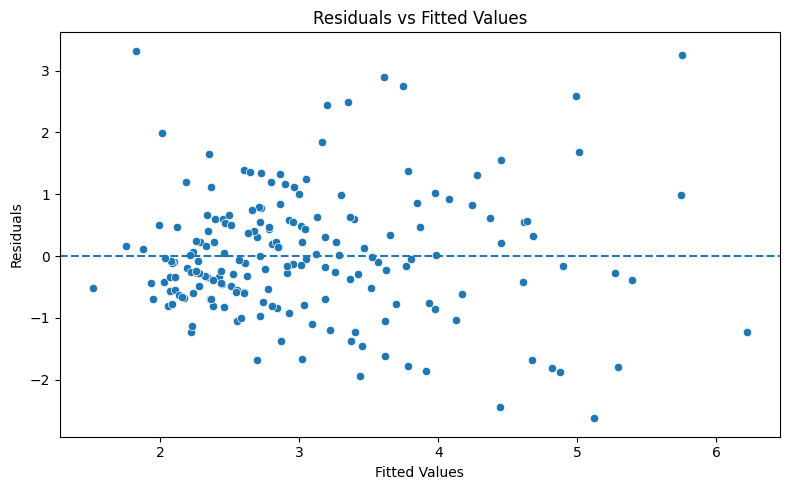

In [56]:
# ============================================================
# Regression Diagnostics: Residuals vs Fitted Values
# ============================================================

# Extract fitted values and residuals
fitted_values = model.fittedvalues
residuals = model.resid

print("Residual Diagnostics Summary")
print("=" * 60)
print(f"Mean of residuals:       {residuals.mean():.6f}")
print(f"Std. deviation:          {residuals.std():.6f}")
print(f"Minimum residual:        {residuals.min():.4f}")
print(f"Maximum residual:        {residuals.max():.4f}")

# Residuals vs fitted plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=fitted_values,
    y=residuals
)

# Reference line at residual = 0
plt.axhline(y=0, linestyle='--')

plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')

plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

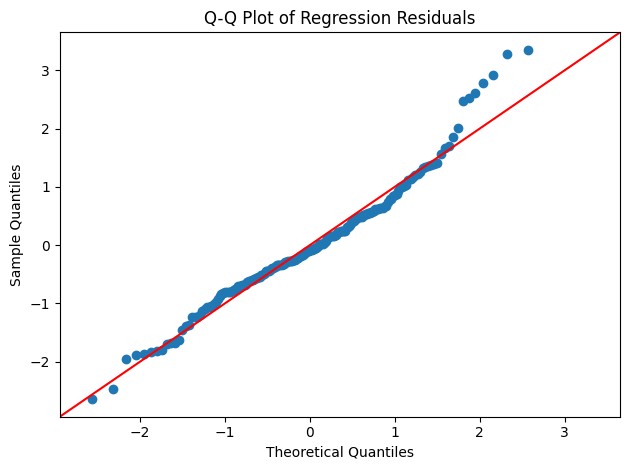

Residual Normality Tests
Jarque-Bera statistic : 21.8538
Jarque-Bera p-value   : 0.000018

Omnibus statistic     : 16.3531
Omnibus p-value       : 0.000281

Interpretation rule:
H0: Regression residuals are normally distributed.
If p-value < 0.05, reject H0.
If p-value >= 0.05, fail to reject H0.


In [57]:
# ============================================================
# Regression Diagnostics: Residual Normality
# Q-Q Plot + Jarque-Bera + Omnibus Tests
# ============================================================

from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Residuals from the fitted OLS model
residuals = model.resid

# ---------------------------
# Q-Q Plot
# ---------------------------
plt.figure(figsize=(7, 5))

sm.qqplot(
    residuals,
    line='45',
    fit=True
)

plt.title('Q-Q Plot of Regression Residuals')
plt.tight_layout()
plt.show()

# ---------------------------
# Jarque-Bera Test
# ---------------------------
jb_stat, jb_pvalue = stats.jarque_bera(residuals)

# ---------------------------
# Omnibus Normality Test
# ---------------------------
omnibus_stat, omnibus_pvalue = stats.normaltest(residuals)

print("Residual Normality Tests")
print("=" * 60)

print(f"Jarque-Bera statistic : {jb_stat:.4f}")
print(f"Jarque-Bera p-value   : {jb_pvalue:.6f}")

print(f"\nOmnibus statistic     : {omnibus_stat:.4f}")
print(f"Omnibus p-value       : {omnibus_pvalue:.6f}")

print("\nInterpretation rule:")
print("H0: Regression residuals are normally distributed.")
print("If p-value < 0.05, reject H0.")
print("If p-value >= 0.05, fail to reject H0.")

### Variance Inflation Factor (VIF)

VIF is used to assess multicollinearity among the continuous predictors.
Lower VIF values indicate that the predictors do not have substantial linear dependence with each other.

In [58]:
# ============================================================
# Regression Diagnostics: Variance Inflation Factor (VIF)
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only the continuous predictors
continuous_predictors = ['total_bill', 'size']

X_vif = X_train[continuous_predictors]

# Calculate VIF for each continuous predictor
vif_table = pd.DataFrame({
    'Variable': continuous_predictors,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

print("Variance Inflation Factor (VIF)")
print("=" * 60)
display(vif_table.round(4))

print("\nInterpretation guideline:")
print("VIF close to 1    -> very low multicollinearity")
print("VIF between 1-5   -> generally acceptable")
print("VIF above 5       -> potentially problematic")
print("VIF above 10      -> serious multicollinearity")

Variance Inflation Factor (VIF)


,Variable,VIF
0,total_bill,1.6332
1,size,1.6332



Interpretation guideline:
VIF close to 1    -> very low multicollinearity
VIF between 1-5   -> generally acceptable
VIF above 5       -> potentially problematic
VIF above 10      -> serious multicollinearity


### Test Set Model Evaluation

The fitted regression model is evaluated on the held-out test set using MAE, MSE, RMSE, and R².
These metrics measure how well the model generalizes to observations that were not used during training.

In [59]:
# ============================================================
# Test Set Prediction and Model Evaluation
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Encode test predictors using the same categorical structure
X_test = pd.get_dummies(
    test_df[predictors],
    columns=['sex', 'smoker', 'day', 'time'],
    drop_first=True,
    dtype=float
)

# Make sure test columns exactly match training columns
X_test = X_test.reindex(
    columns=X_train.columns.drop('const'),
    fill_value=0
)

# Add intercept
X_test = sm.add_constant(X_test, has_constant='add')

# Actual target values
y_test = test_df[target]

# Generate predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
test_r2 = r2_score(y_test, y_pred)

evaluation = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Value': [mae, mse, rmse, test_r2]
})

print("Test Set Model Evaluation")
print("=" * 60)
display(evaluation.round(4))

# Compare actual and predicted values
comparison = pd.DataFrame({
    'Actual Tip': y_test.values,
    'Predicted Tip': y_pred.values,
    'Residual': y_test.values - y_pred.values
})

print("\nSample of Actual vs Predicted Tips:")
display(comparison.head(10).round(3))

Test Set Model Evaluation


,Metric,Value
0,MAE,0.7665
1,MSE,1.1730
2,RMSE,1.0831
3,R²,0.5186



Sample of Actual vs Predicted Tips:


,Actual Tip,Predicted Tip,Residual
0,3.18,2.890,0.290
1,2.00,2.010,-0.010
2,2.74,2.946,-0.206
3,1.47,2.116,-0.646
4,5.92,3.888,2.032
5,3.11,4.020,-0.910
6,3.00,4.183,-1.183
7,2.50,2.463,0.037
8,3.23,2.523,0.707
9,2.55,3.307,-0.757


## Part 2 — Statistical Modeling and Diagnostics: Conclusion

A multiple linear regression model was fitted using OLS to predict `tip` from `total_bill`, `size`, `sex`, `smoker`, `day`, and `time`. The model was statistically significant overall (F-test p < 0.001), with an R² of 0.4452 and an adjusted R² of 0.4213. Among the predictors, `total_bill` and `size` were statistically significant at the 5% significance level, while the categorical predictors did not show sufficient evidence of statistically significant coefficients.

On the held-out test set, the model achieved an MAE of 0.7665, RMSE of 1.0831, and R² of 0.5186, indicating reasonable predictive performance for this dataset. The residuals-versus-fitted plot showed no strong curvature, although the residual spread appeared to increase at higher fitted values, suggesting possible heteroscedasticity.

The Q-Q plot showed deviations from normality, particularly in the tails, and both the Jarque-Bera and Omnibus tests indicated statistically significant departures from normal residuality (p < 0.05). However, the VIF values for the continuous predictors `total_bill` and `size` were both 1.6332, indicating that multicollinearity is not a concern. Overall, the model provides a useful baseline for predicting tips, while its residual diagnostics indicate some limitations that should be considered when interpreting the regression results.

2026-09-14 23:30:43.667 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 23:30:43.668 No runtime found, using MemoryCacheStorageManager
2026-09-14 23:30:43.669 No runtime found, using MemoryCacheStorageManager
2026-09-14 23:30:43.669 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 23:30:43.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 23:30:43.691 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 23:30:43.692 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 23:30:43.692 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 23:30:43.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor